In [1]:
# Import required libraries
import sys
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Add acorn to path
SCRIPT_DIR = Path.cwd()
WORKSPACE_ROOT = SCRIPT_DIR.parent
sys.path.insert(0, str(WORKSPACE_ROOT / 'acorn'))

# Import directly to avoid circular dependency issue
from acorn.stages.graph_construction.models import metric_learning
MetricLearning = metric_learning.MetricLearning

print("Imports successful!")

/data/alice/bkuipers/miniconda3/envs/acorn_notebook/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/alice/bkuipers/miniconda3/envs/acorn_notebook/lib/python3.10/site-packages/lightning_fabric/__init__.py:40: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


Imports successful!


In [2]:
from build_latent_graphs import load_model


checkpoint_name = "low_pt_latent_f1=0.0149.ckpt"
#checkpoint_name = "low_pt_latentmodel_f1_f1=0.0097.ckpt"



checkpoint_path = SCRIPT_DIR / 'saved_models' / checkpoint_name

model, hparams = load_model(checkpoint_path)  



# def load_model(checkpoint_name):

#     checkpoint_path = SCRIPT_DIR / 'saved_models' / checkpoint_name
    
#     if not checkpoint_path.exists():
#         raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    
#     print(f"Loading model from: {checkpoint_path}")
    
#     checkpoint = torch.load(checkpoint_path, map_location='cpu')
    
#     # Extract hyperparameters
#     hparams = checkpoint['hyper_parameters']
    
#     print(f"  Model architecture:")
#     print(f"    Input features: {hparams['node_features']}")
#     print(f"    Hidden layers: {hparams['nb_layer']} x {hparams['emb_hidden']}")
#     print(f"    Embedding dim: {hparams['emb_dim']}D")
#     print(f"    Activation: {hparams['activation']}")

#     # Create model instance and load weights
#     model = MetricLearning(hparams)
#     model.load_state_dict(checkpoint['state_dict'])
#     model.eval()
    
#     return model, hparams

# Load the model
# model, hparams = load_model('latentmodel_val_loss=0.0048.ckpt')  # Change this to your model name

Loading model from: /data/alice/bkuipers/low_pt_gnn_pipeline/saved_models/low_pt_latent_f1=0.0149.ckpt
  Model architecture:
    Input features: ['hit_r', 'hit_phi', 'hit_z']
    Hidden layers: 4 x 64
    Embedding dim: 8D
    Activation: Tanh



In [4]:
example_graph = "event000000000-graph.pyg"

#graph = torch.load(SCRIPT_DIR / 'data' / 'feature_store' /'trainset'/ example_graph)


graph = torch.load(SCRIPT_DIR / "All data"/"data_0.1-0.5GeV"/f'feature_store' /'trainset'/ example_graph)

def map_to_latent_space(model, graph, node_features):
    # Extract features from graph
    feature_list = []
    for feat_name in node_features:
        feature_list.append(getattr(graph, feat_name))

    
    x = torch.stack(feature_list, dim=1).float()
    # Get embeddings
    with torch.no_grad():
        embeddings = model(x)
    return embeddings



# Map hits to latent space
embeddings = map_to_latent_space(model, graph, hparams['node_features'])

print(f"Embeddings shape: {embeddings.shape}")
print(f"Embedding dimension: {embeddings.shape[1]}D")

Embeddings shape: torch.Size([306, 8])
Embedding dimension: 8D


In [5]:
graph

Data(hit_particle_id=[306], hit_r=[306], hit_y=[306], hit_z=[306], hit_phi=[306], hit_id=[306], hit_eta=[306], hit_region=[306], hit_x=[306], track_edges=[2, 286], track_particle_radius=[286], track_particle_pt=[286], track_particle_id=[286], track_particle_eta=[286], track_particle_nhits=[286], config=[1], event_id='000000000')

Total variance explained: 98.27% (eigen value fraction)


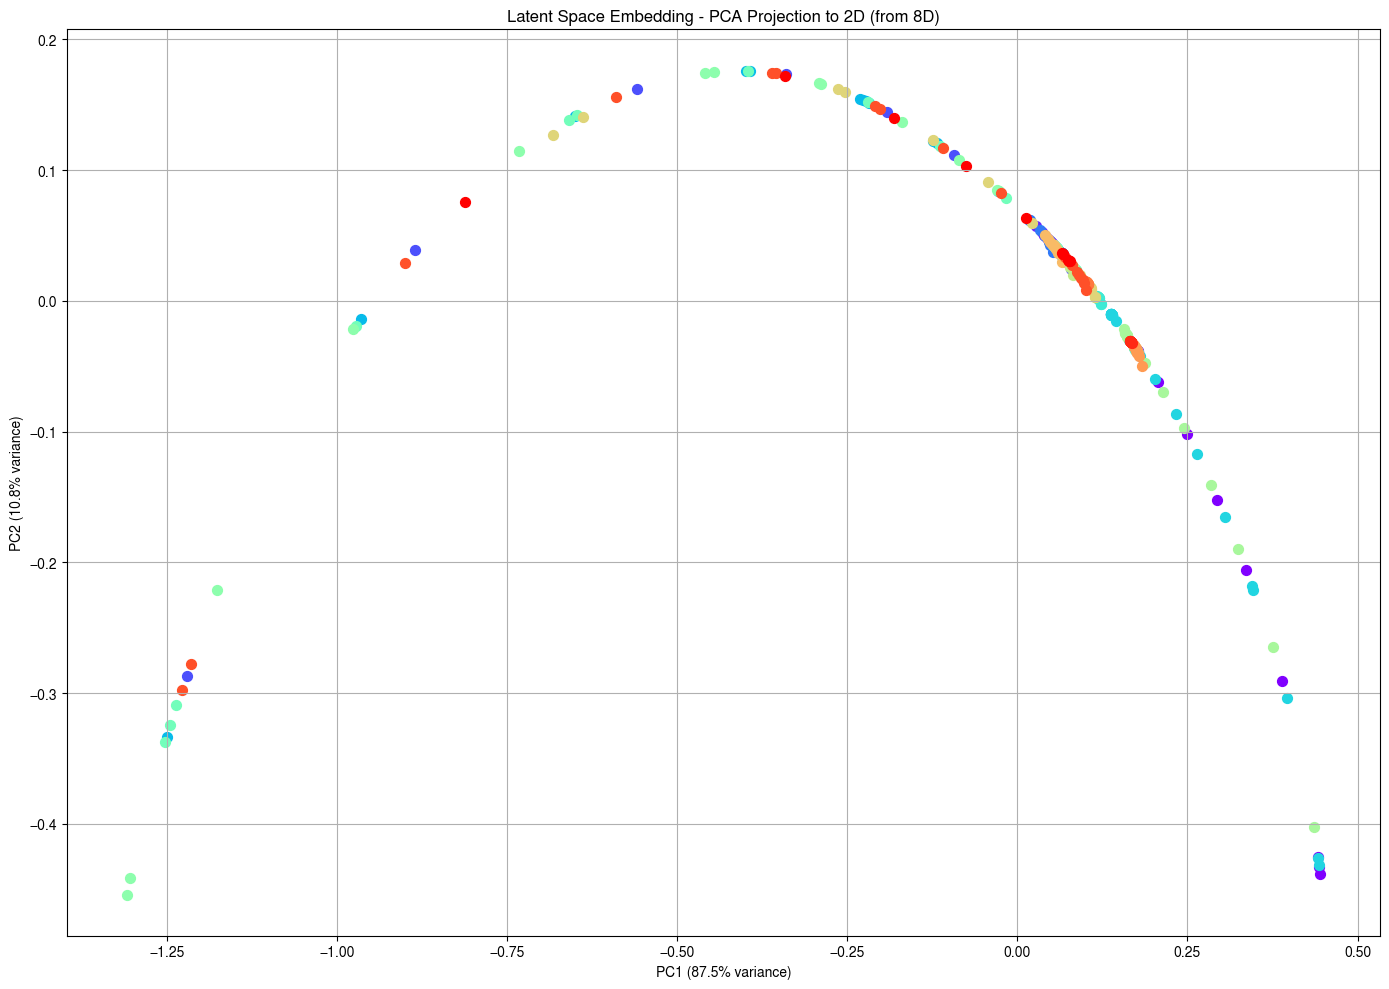

In [6]:
# Visualize latent space with PCA to 2D
from sklearn.decomposition import PCA

emb_np = embeddings.cpu().detach().numpy()
particle_ids = graph.hit_particle_id.cpu().detach().numpy()

particle_ids = np.asarray(particle_ids, dtype=np.int64)

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_np)

#print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%} (eigen value fraction)")

# Create 2D scatter plot
fig, ax = plt.subplots(figsize=(14, 10))

# Color by particle ID (limit to a few particles for clarity)
unique_pids = np.unique(particle_ids)
unique_pids = unique_pids[unique_pids > 0]  # Remove noise

import matplotlib.cm as cm
colors = cm.rainbow(np.linspace(0, 1, min(len(unique_pids), 20)))

for i, pid in enumerate(unique_pids[:20]):  # Plot first 20 particles
    mask = particle_ids == pid
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], 
               c=[colors[i]], label=f'Particle {pid}', s=50)


ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title(f'Latent Space Embedding - PCA Projection to 2D (from {embeddings.shape[1]}D)')

ax.grid(True)

plt.tight_layout()
plt.show()
